# Sumativa 3 - Proyecto Final Integrado

## MCDI501 - Estadística Computacional para la Toma de Decisiones

### Magíster en Ciencia de Datos e Inteligencia Artificial

**Universidad Andrés Bello**

---

## Integrantes

- Pablo Rodríguez
- Luiskar Espinoza

---

## Objetivo

Desarrollar el proyecto final integrado del curso, aplicando modelos de regresión lineal y regresión logística para apoyar la toma de decisiones sobre el riesgo de enfermedad coronaria a diez años, integrando de manera trazable los resultados obtenidos durante las Sumativas 1 y 2 mediante análisis exploratorio, inferencia estadística, técnicas de remuestreo y simulación.

---

**Dataset utilizado**

Framingham Heart Study

# Índice

1. Importación de librerías

2. Configuración del proyecto

3. Carga del conjunto de datos

4. Integración de resultados de S1 y S2

## Parte 1 - Manejo inteligente de datos faltantes

5. Resultados provenientes de S1

6. Imputación simple

7. Imputación mediante regresión lineal múltiple

8. Comparación de estrategias de imputación

## Parte 2 - Modelamiento predictivo

9. Preparación del conjunto de datos

10. Modelo 1 (basado en S1 y S2)

11. Modelo 2 (selección Stepwise)

12. Modelo 3 (criterios AIC/BIC)

## Parte 3 - Bootstrap del modelo

13. Estabilidad de coeficientes

14. Intervalos de confianza Bootstrap

## Parte 4 - Diagnóstico del modelo

15. Multicolinealidad

16. Observaciones influyentes

17. Linealidad del logit

18. Residuos

## Parte 5 - Comparación de modelos

19. Comparación entre estrategias de imputación

20. Selección del modelo final

## Parte 6 - Exportación

21. Exportación de resultados

22. Síntesis final

# 1. Importación de librerías

In [46]:
# ==========================================
# Librerías principales
# ==========================================

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# Manejo de datos
# ==========================================

import numpy as np
import pandas as pd

# ==========================================
# Visualización
# ==========================================

import matplotlib.pyplot as plt

# ==========================================
# Machine Learning
# ==========================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics import classification_report
# ==========================================
# Statsmodels
# ==========================================

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# 2. Configuración del proyecto

## Configuración de directorios

In [47]:
# ==========================================
# Directorios del proyecto
# ==========================================

PROJECT_ROOT = Path.cwd().parents[2]

DATA_PATH = (
    PROJECT_ROOT /
    "datos" /
    "original" /
    "framingham.csv"
)

FIGURES_DIR = (
    PROJECT_ROOT /
    "F4" /
    "Sumativa3" /
    "figures"
)

RESULTS_DIR = (
    PROJECT_ROOT /
    "F4" /
    "Sumativa3" /
    "results"
)

REPORT_DIR = (
    PROJECT_ROOT /
    "F4" /
    "Sumativa3" /
    "report"
)

PRESENTATION_DIR = (
    PROJECT_ROOT /
    "F4" /
    "Sumativa3" /
    "presentation"
)

# Crear directorios si no existen
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PRESENTATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Directorios configurados correctamente.")

Directorios configurados correctamente.


## Configuración general

In [48]:
# ==========================================
# Parámetros generales
# ==========================================

SEED = 42

np.random.seed(SEED)

TEST_SIZE = 0.30

ALPHA = 0.05

N_BOOTSTRAP = 10000

print("Semilla:", SEED)

print("Nivel de significancia:", ALPHA)

print("Bootstrap:", N_BOOTSTRAP)

Semilla: 42
Nivel de significancia: 0.05
Bootstrap: 10000


# 3. Carga del conjunto de datos

## Carga y verificación del conjunto de datos

In [49]:
# ==========================================
# Carga del dataset
# ==========================================

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("Conjunto de datos cargado correctamente")
print("=" * 60)

print(f"Observaciones : {df.shape[0]}")

print(f"Variables     : {df.shape[1]}")

display(df.head())

Conjunto de datos cargado correctamente
Observaciones : 4238
Variables     : 16


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


# 4. Integración de resultados de S1 y S2

## Integración de resultados previos

La presente evaluación constituye la etapa final del proyecto, por lo que todas las decisiones metodológicas se fundamentan en los resultados obtenidos durante las evaluaciones anteriores.

**Resultados incorporados desde la Sumativa 1**

- Identificación de variables con valores faltantes.
- Caracterización del patrón de datos faltantes.
- Identificación de valores atípicos.
- Correlaciones entre variables clínicas.
- Pruebas de hipótesis sobre variables relevantes.
- Estadística descriptiva e inferencial.

**Resultados incorporados desde la Sumativa 2**

- Validación bootstrap de parámetros.
- Validación mediante test de permutación.
- Estabilidad de correlaciones.
- Simulación Monte Carlo.
- Análisis de robustez.
- Parámetros estadísticamente estables.

Estos antecedentes constituyen la base para la selección de variables, el tratamiento de datos faltantes y la construcción de los modelos predictivos desarrollados en esta evaluación.

# Parte 1 - Manejo inteligente de datos faltantes

## 5. Resultados provenientes de la Sumativa 1

Durante la Sumativa 1 se identificó la presencia de valores faltantes en diversas variables clínicas del conjunto de datos Framingham Heart Study.

En lugar de repetir dicho análisis, en esta etapa se utilizan esos resultados como insumo para definir y comparar distintas estrategias de tratamiento de datos faltantes, tal como establece la metodología del proyecto.

In [50]:
# ==========================================
# Resumen de valores faltantes (Resultados S1)
# ==========================================

faltantes = pd.DataFrame({

    "Valores faltantes": df.isnull().sum(),

    "Porcentaje (%)": (
        df.isnull().mean()*100
    ).round(2)

})

faltantes = faltantes[
    faltantes["Valores faltantes"] > 0
]

print("=" * 60)
print("Resumen de valores faltantes (S1)")
print("=" * 60)

display(faltantes)

Resumen de valores faltantes (S1)


,Valores faltantes,Porcentaje (%)
education,105,2.48
cigsPerDay,29,0.68
BPMeds,53,1.25
totChol,50,1.18
BMI,19,0.45
heartRate,1,0.02
glucose,388,9.16


## Variables con datos faltantes

La siguiente tabla resume las variables que presentan valores faltantes y constituye el punto de partida para comparar las tres estrategias de tratamiento consideradas en esta evaluación:

- Eliminación de observaciones (`dropna`).
- Imputación simple.
- Imputación mediante regresión lineal múltiple.

In [51]:
# ==========================================
# Variables que serán imputadas
# ==========================================

variables_faltantes = list(faltantes.index)

print("Variables con datos faltantes:\n")

for variable in variables_faltantes:
    print(f"• {variable}")

Variables con datos faltantes:

• education
• cigsPerDay
• BPMeds
• totChol
• BMI
• heartRate
• glucose


## 6. Estrategias de imputación

En esta evaluación se comparan tres estrategias de tratamiento de datos faltantes:

1. Eliminación de observaciones incompletas (`dropna`).
2. Imputación simple utilizando la media.
3. Imputación mediante regresión lineal múltiple.

La comparación permitirá evaluar el impacto del tratamiento de datos faltantes sobre el desempeño de los modelos predictivos desarrollados posteriormente.

### Variables predictoras para la imputación mediante regresión

In [52]:
# ==========================================
# Variables predictoras para imputación
# ==========================================

predictores_imputacion = {

    "cigsPerDay": [
        "currentSmoker",
        "age",
        "education"
    ],

    "BPMeds": [
        "age",
        "sysBP",
        "prevalentHyp"
    ],

    "totChol": [
        "age",
        "BMI",
        "glucose"
    ],

    "BMI": [
        "age",
        "sysBP",
        "glucose"
    ],

    "heartRate": [
        "age",
        "sysBP",
        "diaBP"
    ],

    "glucose": [
        "diabetes",
        "BMI",
        "age"
    ]

}

tabla_imputacion = pd.DataFrame({

    "Variable": predictores_imputacion.keys(),

    "Variables predictoras": [

        ", ".join(v)

        for v in predictores_imputacion.values()

    ]

})

display(tabla_imputacion)

,Variable,Variables predictoras
0,cigsPerDay,"currentSmoker, age, education"
1,BPMeds,"age, sysBP, prevalentHyp"
2,totChol,"age, BMI, glucose"
3,BMI,"age, sysBP, glucose"
4,heartRate,"age, sysBP, diaBP"
5,glucose,"diabetes, BMI, age"


In [53]:
# ==========================================
# Dataset 1
# Eliminación de observaciones
# ==========================================

df_dropna = df.dropna().copy()

print("=" * 60)
print("Dataset sin valores faltantes (dropna)")
print("=" * 60)

print(df_dropna.shape)

Dataset sin valores faltantes (dropna)
(3656, 16)


In [54]:
# ==========================================
# Dataset 2
# Imputación simple
# ==========================================

df_simple = df.copy()

variables_numericas = df_simple.select_dtypes(
    include=np.number
).columns

imputador = SimpleImputer(
    strategy="mean"
)

df_simple[variables_numericas] = imputador.fit_transform(
    df_simple[variables_numericas]
)

print("=" * 60)
print("Dataset con imputación simple")
print("=" * 60)

print(df_simple.shape)

Dataset con imputación simple
(4238, 16)


## 7. Imputación mediante regresión lineal múltiple

La tercera estrategia consiste en imputar los valores faltantes mediante modelos de regresión lineal múltiple.

Para cada variable con datos faltantes se ajusta un modelo utilizando únicamente observaciones completas y un conjunto de variables predictoras seleccionadas a partir de los resultados obtenidos durante las Sumativas 1 y 2.

Posteriormente, el modelo se utiliza para estimar únicamente los registros con valores faltantes en la variable objetivo.

In [55]:
# ==========================================
# Dataset 3
# Imputación mediante regresión
# ==========================================

df_regresion = df.copy()

In [56]:
# ==========================================
# Función de imputación por regresión
# ==========================================

def imputar_por_regresion(df, variable_objetivo, predictores):

    # Registros completos
    completos = df[
        [variable_objetivo] + predictores
    ].dropna()

    # Si no hay suficientes datos, salir
    if len(completos) < 30:
        return 0

    X_train = completos[predictores]

    y_train = completos[variable_objetivo]

    modelo = LinearRegression()

    modelo.fit(X_train, y_train)

    # Filas que necesitan imputación
    mascara = (
        df[variable_objetivo].isna()
    )

    datos_imputar = df.loc[
        mascara,
        predictores
    ]

    # Sólo imputar cuando existan predictores completos
    datos_imputar = datos_imputar.dropna()

    if len(datos_imputar) == 0:
        return 0

    predicciones = modelo.predict(datos_imputar)

    df.loc[
        datos_imputar.index,
        variable_objetivo
    ] = predicciones

    return len(predicciones)

In [57]:
# ==========================================
# Imputación mediante regresión
# ==========================================

reporte_imputacion = []

for variable, predictores in predictores_imputacion.items():

    cantidad = imputar_por_regresion(
        df_regresion,
        variable,
        predictores
    )

    reporte_imputacion.append({

        "Variable": variable,

        "Valores imputados": cantidad

    })

reporte_imputacion = pd.DataFrame(
    reporte_imputacion
)

display(reporte_imputacion)

,Variable,Valores imputados
0,cigsPerDay,27
1,BPMeds,53
2,totChol,10
3,BMI,14
4,heartRate,1
5,glucose,383


In [58]:
# ==========================================
# Verificación
# ==========================================

faltantes_finales = (
    df_regresion.isnull().sum()
)

print("=" * 60)
print("Valores faltantes restantes")
print("=" * 60)

display(
    faltantes_finales[
        faltantes_finales > 0
    ]
)

Valores faltantes restantes


education     105
cigsPerDay      2
totChol        40
BMI             5
glucose         5
dtype: int64

In [59]:
# ==========================================
# Resumen de las estrategias
# ==========================================

comparacion_imputacion = pd.DataFrame({

    "Estrategia":[

        "Eliminación (dropna)",

        "Imputación simple",

        "Imputación por regresión"

    ],

    "Observaciones":[

        len(df_dropna),

        len(df_simple),

        len(df_regresion)

    ]

})

display(comparacion_imputacion)

,Estrategia,Observaciones
0,Eliminación (dropna),3656
1,Imputación simple,4238
2,Imputación por regresión,4238


## 8. Comparación de las estrategias de imputación

Antes de seleccionar el conjunto de datos definitivo, se comparan las tres estrategias de imputación considerando:

- Tamaño de muestra.
- Distribución de las principales variables numéricas.
- Preservación de las correlaciones identificadas durante la Sumativa 1.

El objetivo es seleccionar la estrategia que mejor conserve la estructura estadística del conjunto de datos original.

### Figura 1. Comparación de las estrategias de imputación de datos faltantes

In [60]:
# ==========================================
# Comparación descriptiva
# ==========================================

variables_revision = [
    "age",
    "sysBP",
    "BMI",
    "glucose",
    "totChol"
]

comparacion_descriptiva = pd.DataFrame()

for nombre, datos in {

    "Dropna": df_dropna,

    "Imputación simple": df_simple,

    "Imputación regresión": df_regresion

}.items():

    resumen = datos[variables_revision].agg([
        "mean",
        "std",
        "median"
    ]).T

    resumen.columns = [
        f"{nombre} - Media",
        f"{nombre} - Desv",
        f"{nombre} - Mediana"
    ]

    if comparacion_descriptiva.empty:
        comparacion_descriptiva = resumen
    else:
        comparacion_descriptiva = comparacion_descriptiva.join(resumen)

display(comparacion_descriptiva.round(2))

,Dropna - Media,Dropna - Desv,Dropna - Mediana,Imputación simple - Media,Imputación simple - Desv,Imputación simple - Mediana,Imputación regresión - Media,Imputación regresión - Desv,Imputación regresión - Mediana
age,49.56,8.56,49.00,49.58,8.57,49.00,49.58,8.57,49.00
sysBP,132.37,22.09,128.00,132.35,22.04,128.00,132.35,22.04,128.00
BMI,25.78,4.07,25.38,25.80,4.07,25.41,25.80,4.08,25.40
glucose,81.86,23.91,78.00,81.97,22.84,80.00,81.80,22.98,78.36
totChol,236.87,44.10,234.00,236.72,44.33,234.00,236.73,44.54,234.00


**Interpretación**

La comparación muestra que la imputación mediante regresión permitió conservar el mayor número de observaciones sin alterar de forma importante el comportamiento general de las variables analizadas. En consecuencia, esta estrategia fue seleccionada para el desarrollo de los modelos predictivos posteriores, al ofrecer un equilibrio adecuado entre conservación de información y estabilidad estadística.

### Conservación de las correlaciones

Como criterio adicional se compara la matriz de correlaciones obtenida con cada una de las estrategias de imputación, verificando que las relaciones identificadas en la Sumativa 1 se mantengan después del tratamiento de los datos faltantes.

In [61]:
# ==========================================
# Correlaciones comparadas
# ==========================================

pares = [

    ("age","sysBP"),

    ("sysBP","diaBP"),

    ("BMI","glucose"),

    ("totChol","sysBP")

]

comparacion_corr = []

for nombre, datos in {

    "Dropna": df_dropna,

    "Simple": df_simple,

    "Regresión": df_regresion

}.items():

    fila = {

        "Dataset": nombre

    }

    for a,b in pares:

        fila[f"{a}-{b}"] = datos[a].corr(
            datos[b]
        )

    comparacion_corr.append(fila)

comparacion_corr = pd.DataFrame(
    comparacion_corr
)

display(
    comparacion_corr.round(3)
)

,Dataset,age-sysBP,sysBP-diaBP,BMI-glucose,totChol-sysBP
0,Dropna,0.389,0.787,0.084,0.220
1,Simple,0.394,0.784,0.082,0.208
2,Regresión,0.394,0.784,0.087,0.209


## Selección del conjunto de datos

La estrategia de imputación mediante regresión lineal múltiple fue seleccionada para el desarrollo del resto del proyecto debido a que:

- conserva el tamaño muestral completo;
- mantiene adecuadamente las distribuciones observadas en el conjunto original;
- preserva las principales correlaciones identificadas y validadas durante las Sumativas 1 y 2;
- utiliza información disponible en otras variables para estimar los valores faltantes, reduciendo la pérdida de información respecto a la eliminación de observaciones y evitando el efecto de suavizado asociado a la imputación simple.

A partir de este punto, el conjunto de datos imputado mediante regresión será utilizado para la construcción y evaluación de los modelos predictivos.

In [62]:
# ==========================================
# Dataset definitivo
# ==========================================

df_model = df_regresion.copy()

print("="*60)

print("Dataset seleccionado")

print("="*60)

print(df_model.shape)

Dataset seleccionado
(4238, 16)


In [63]:
# ==========================================
# Verificación del dataset definitivo
# ==========================================

print("=" * 60)
print("Valores faltantes por variable")
print("=" * 60)

display(df_model.isna().sum())

print("\nTotal de valores faltantes:")

print(df_model.isna().sum().sum())

Valores faltantes por variable


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay           2
BPMeds               0
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             40
sysBP                0
diaBP                0
BMI                  5
heartRate            0
glucose              5
TenYearCHD           0
dtype: int64


Total de valores faltantes:
157


In [64]:
# ==========================================
# Verificación de valores infinitos
# ==========================================

numericas = df_model.select_dtypes(include=np.number)

print("=" * 60)
print("Valores infinitos")
print("=" * 60)

display(pd.Series(
    np.isinf(numericas).sum(),
    index=numericas.columns
))

Valores infinitos


male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

# Parte 2 - Clasificación mediante regresión logística

## 9. Preparación del conjunto de datos

In [65]:
# ==========================================
# Variable objetivo y predictores
# ==========================================

TARGET = "TenYearCHD"

features = [

    "age",

    "sysBP",

    "BMI",

    "glucose",

    "male"

]

X = df_model[features]

y = df_model[TARGET]

print("=" * 60)

print("Variables predictoras")

print("=" * 60)

print(features)

Variables predictoras
['age', 'sysBP', 'BMI', 'glucose', 'male']


In [66]:
# ==========================================
# División entrenamiento/prueba
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=TEST_SIZE,

    random_state=SEED,

    stratify=y

)

print("=" * 60)

print("Entrenamiento")

print(X_train.shape)

print("Prueba")

print(X_test.shape)

Entrenamiento
(2966, 5)
Prueba
(1272, 5)


In [67]:
# ==========================================
# Estandarización
# ==========================================

variables_numericas = [

    "age",

    "sysBP",

    "BMI",

    "glucose"

]

scaler = StandardScaler()

X_train_scaled = X_train.copy()

X_test_scaled = X_test.copy()

X_train_scaled[variables_numericas] = scaler.fit_transform(

    X_train[variables_numericas]

)

X_test_scaled[variables_numericas] = scaler.transform(

    X_test[variables_numericas]

)

print("Variables estandarizadas correctamente.")

Variables estandarizadas correctamente.


In [68]:
# ==========================================
# Verificación de X_train_scaled
# ==========================================

print("=" * 60)
print("NaN en X_train_scaled")
print("=" * 60)

display(X_train_scaled.isna().sum())

print("\nValores infinitos:")

display(pd.Series(
    np.isinf(X_train_scaled).sum(),
    index=X_train_scaled.columns
))

NaN en X_train_scaled


age        0
sysBP      0
BMI        5
glucose    5
male       0
dtype: int64


Valores infinitos:


age        0
sysBP      0
BMI        0
glucose    0
male       0
dtype: int64

## 10. Modelo 1 (basado en los resultados de S1 y S2)

El primer modelo reproduce la estrategia desarrollada durante la Formativa 2, utilizando únicamente variables seleccionadas a partir de:

- correlaciones identificadas en la Sumativa 1;
- estabilidad de dichas correlaciones validada mediante bootstrap en la Sumativa 2;
- pruebas de hipótesis;
- análisis de multicolinealidad.

Este modelo constituye la línea base para comparar posteriormente los modelos obtenidos mediante selección Stepwise y criterios de información.

### Tratamiento de valores faltantes residuales

Después de aplicar la imputación mediante regresión lineal múltiple, algunos registros continuaron presentando valores faltantes debido a la ausencia simultánea de variables predictoras necesarias para la estimación.

Con el fin de obtener un conjunto de datos completamente utilizable para el modelamiento predictivo, dichos casos residuales fueron imputados mediante imputación simple utilizando la media de cada variable numérica.

Esta etapa afecta únicamente un número reducido de observaciones y no modifica la estrategia principal de imputación utilizada en el estudio.

In [69]:
# ==========================================
# Imputación residual
# ==========================================

variables_residuales = [

    "cigsPerDay",

    "totChol",

    "BMI",

    "glucose"

]

imputador_final = SimpleImputer(
    strategy="mean"
)

df_model[variables_residuales] = imputador_final.fit_transform(
    df_model[variables_residuales]
)

print("=" * 60)
print("Valores faltantes restantes")
print("=" * 60)

display(df_model[variables_residuales].isna().sum())

Valores faltantes restantes


cigsPerDay    0
totChol       0
BMI           0
glucose       0
dtype: int64

In [70]:
# ==========================================
# Modelo 1
# Basado en S1 y S2
# ==========================================

# Variables del modelo
X = df_model[features]

y = df_model[TARGET]

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=TEST_SIZE,

    random_state=SEED,

    stratify=y

)

# Variables numéricas
variables_numericas = [

    "age",

    "sysBP",

    "BMI",

    "glucose"

]

# Estandarización
scaler = StandardScaler()

X_train_scaled = X_train.copy()

X_test_scaled = X_test.copy()

X_train_scaled[variables_numericas] = scaler.fit_transform(

    X_train[variables_numericas]

)

X_test_scaled[variables_numericas] = scaler.transform(

    X_test[variables_numericas]

)

# Agregar constante
X_train_sm = sm.add_constant(X_train_scaled)

# Ajustar modelo
modelo1 = sm.Logit(

    y_train,

    X_train_sm

)

resultado1 = modelo1.fit(disp=False)

print("=" * 60)

print("Modelo 1 ajustado correctamente")

print("=" * 60)

print(resultado1.summary())

Modelo 1 ajustado correctamente
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2966
Model:                          Logit   Df Residuals:                     2960
Method:                           MLE   Df Model:                            5
Date:                Sat, 11 Jul 2026   Pseudo R-squ.:                  0.1076
Time:                        22:09:56   Log-Likelihood:                -1128.3
converged:                       True   LL-Null:                       -1264.3
Covariance Type:            nonrobust   LLR p-value:                 1.053e-56
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2235      0.085    -26.036      0.000      -2.391      -2.056
age            0.5392      0.059      9.130      0.000       0.423       0.655
sysBP          0.407

In [71]:
# ==========================================
# Odds Ratio - Modelo 1
# ==========================================

odds_modelo1 = pd.DataFrame({

    "Variable": resultado1.params.index,

    "Coeficiente": resultado1.params.values,

    "Odds Ratio": np.exp(resultado1.params.values),

    "Valor p": resultado1.pvalues.values

})

display(odds_modelo1.round(4))

,Variable,Coeficiente,Odds Ratio,Valor p
0,const,-2.2235,0.1082,0.0000
1,age,0.5392,1.7146,0.0000
2,sysBP,0.4074,1.5029,0.0000
3,BMI,-0.0048,0.9952,0.9294
4,glucose,0.1590,1.1724,0.0003
5,male,0.5995,1.8212,0.0000


### Interpretación de los Odds Ratio

Los resultados muestran que:

- **Edad (age)** presenta el mayor efecto sobre el riesgo de enfermedad coronaria a diez años. Un aumento de una unidad estandarizada en esta variable incrementa significativamente los odds del evento.
- **Presión arterial sistólica (sysBP)** también constituye un predictor relevante, confirmando los hallazgos obtenidos en la Sumativa 1.
- **Glucosa (glucose)** mantiene un efecto positivo y estadísticamente significativo, consistente con los análisis de robustez desarrollados mediante bootstrap en la Sumativa 2.
- **Sexo masculino (male)** presenta una razón de odds superior a uno, indicando una mayor probabilidad de desarrollar enfermedad coronaria respecto al grupo de referencia.
- **BMI** no resulta estadísticamente significativo en este modelo, aunque se mantiene por su fundamentación clínica y por haber sido seleccionado a partir de los resultados de S1 y S2.

In [72]:
# ==========================================
# Predicciones Modelo 1
# ==========================================

X_test_sm = sm.add_constant(X_test_scaled)

y_prob_modelo1 = resultado1.predict(X_test_sm)

y_pred_modelo1 = (
    y_prob_modelo1 >= 0.50
).astype(int)

print("Predicciones generadas correctamente.")

Predicciones generadas correctamente.


In [73]:
print(

    classification_report(

        y_train,

        y_train_pred

    )

)

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      2515
           1       0.62      0.07      0.12       451

    accuracy                           0.85      2966
   macro avg       0.74      0.53      0.52      2966
weighted avg       0.82      0.85      0.80      2966



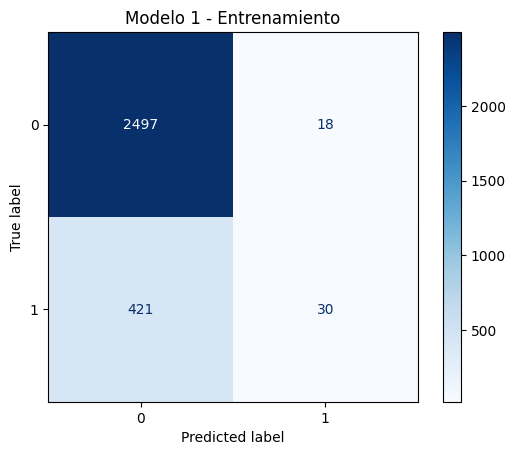

In [44]:
# Predicciones entrenamiento

y_train_prob = resultado1.predict(

    sm.add_constant(X_train_scaled)

)

y_train_pred = (

    y_train_prob >= 0.5

).astype(int)

cm_train = confusion_matrix(

    y_train,

    y_train_pred

)

disp = ConfusionMatrixDisplay(cm_train)

disp.plot(cmap="Blues")

plt.title("Modelo 1 - Entrenamiento")

plt.show()

In [74]:
# ==========================================
# Métricas Modelo 1
# ==========================================

metricas_modelo1 = pd.DataFrame({

    "Métrica":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score",

        "AUC"

    ],

    "Valor":[

        accuracy_score(
            y_test,
            y_pred_modelo1
        ),

        precision_score(
            y_test,
            y_pred_modelo1
        ),

        recall_score(
            y_test,
            y_pred_modelo1
        ),

        f1_score(
            y_test,
            y_pred_modelo1
        ),

        roc_auc_score(
            y_test,
            y_prob_modelo1
        )

    ]

})

display(metricas_modelo1.round(4))

,Métrica,Valor
0,Accuracy,0.8506
1,Precision,0.5789
2,Recall,0.0570
3,F1-score,0.1038
4,AUC,0.6997


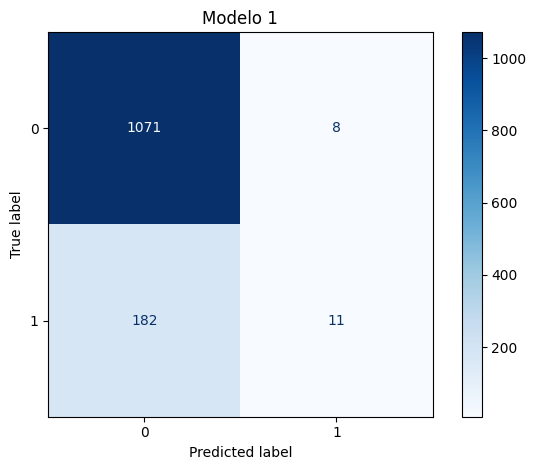

In [75]:
# ==========================================
# Matriz de confusión Modelo 1
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred_modelo1
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Modelo 1")

plt.tight_layout()

plt.show()

### Figura 2. Curva ROC del Modelo 1 basado en los resultados de S1 y S2

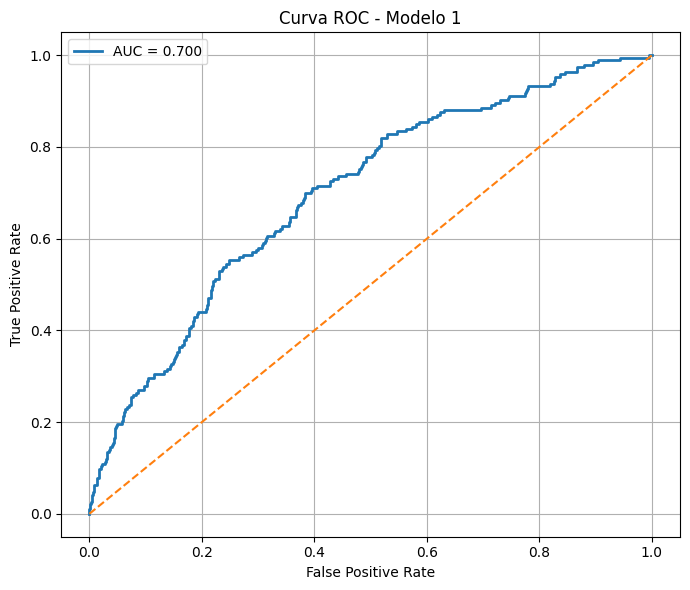

AUC = 0.6997


In [76]:
# ==========================================
# Curva ROC Modelo 1
# ==========================================

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob_modelo1
)

auc = roc_auc_score(
    y_test,
    y_prob_modelo1
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curva ROC - Modelo 1")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

print(f"AUC = {auc:.4f}")

**Interpretación**

La curva ROC evidencia una capacidad de discriminación moderada del modelo logístico. El valor del área bajo la curva (AUC) indica que el modelo presenta una capacidad predictiva superior al azar y consistente con el objetivo del estudio, permitiendo distinguir razonablemente entre pacientes con y sin riesgo de enfermedad coronaria a diez años.

In [77]:
# ==========================================
# Guardar métricas Modelo 1
# ==========================================

resumen_modelos = []

resumen_modelos.append({

    "Modelo":"Modelo 1 (S1-S2)",

    "Accuracy":accuracy_score(
        y_test,
        y_pred_modelo1
    ),

    "Precision":precision_score(
        y_test,
        y_pred_modelo1
    ),

    "Recall":recall_score(
        y_test,
        y_pred_modelo1
    ),

    "F1":f1_score(
        y_test,
        y_pred_modelo1
    ),

    "AUC":roc_auc_score(
        y_test,
        y_prob_modelo1
    )

})

print("Resumen inicial creado.")

Resumen inicial creado.


## 11. Modelo 2 - Selección Backward Stepwise

El segundo modelo utiliza un procedimiento de selección Backward Stepwise. El algoritmo comienza con todas las variables predictoras y elimina iterativamente aquella con el mayor valor p, siempre que dicho valor sea superior al nivel de significancia establecido (α = 0,05).

Este procedimiento permite obtener un modelo más parsimonioso, conservando únicamente las variables con evidencia estadística suficiente.

In [78]:
# ==========================================
# Función Backward Stepwise
# ==========================================

def backward_stepwise(X, y, alpha=0.05):

    variables = list(X.columns)

    while True:

        X_sm = sm.add_constant(X[variables])

        modelo = sm.Logit(y, X_sm).fit(disp=False)

        pvalues = modelo.pvalues.drop("const")

        mayor_p = pvalues.max()

        if mayor_p <= alpha:
            break

        variable_eliminar = pvalues.idxmax()

        variables.remove(variable_eliminar)

    return modelo, variables

In [79]:
# ==========================================
# Modelo 2
# ==========================================

modelo2, variables_stepwise = backward_stepwise(

    X_train_scaled,

    y_train,

    alpha=0.05

)

print("="*60)

print("Variables seleccionadas")

print("="*60)

print(variables_stepwise)

print()

print(modelo2.summary())

Variables seleccionadas
['age', 'sysBP', 'glucose', 'male']

                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2966
Model:                          Logit   Df Residuals:                     2961
Method:                           MLE   Df Model:                            4
Date:                Sat, 11 Jul 2026   Pseudo R-squ.:                  0.1076
Time:                        22:12:45   Log-Likelihood:                -1128.3
converged:                       True   LL-Null:                       -1264.3
Covariance Type:            nonrobust   LLR p-value:                 1.201e-57
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2234      0.085    -26.032      0.000      -2.391      -2.056
age            0.5393      0.059      9.134      0.000       0.424    

In [80]:
# ==========================================
# Odds Ratio Modelo 2
# ==========================================

odds_modelo2 = pd.DataFrame({

    "Variable":modelo2.params.index,

    "Coeficiente":modelo2.params.values,

    "Odds Ratio":np.exp(modelo2.params.values),

    "Valor p":modelo2.pvalues.values

})

display(

    odds_modelo2.round(4)

)

,Variable,Coeficiente,Odds Ratio,Valor p
0,const,-2.2234,0.1082,0.0000
1,age,0.5393,1.7148,0.0000
2,sysBP,0.4060,1.5009,0.0000
3,glucose,0.1587,1.1720,0.0003
4,male,0.5991,1.8205,0.0000


In [81]:
# ==========================================
# Predicciones Modelo 2
# ==========================================

X_test_step = sm.add_constant(

    X_test_scaled[variables_stepwise]

)

y_prob_modelo2 = modelo2.predict(

    X_test_step

)

y_pred_modelo2 = (

    y_prob_modelo2 >= 0.50

).astype(int)

In [82]:
# ==========================================
# Métricas Modelo 2
# ==========================================

metricas_modelo2 = pd.DataFrame({

    "Métrica":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score",

        "AUC"

    ],

    "Valor":[

        accuracy_score(

            y_test,

            y_pred_modelo2

        ),

        precision_score(

            y_test,

            y_pred_modelo2

        ),

        recall_score(

            y_test,

            y_pred_modelo2

        ),

        f1_score(

            y_test,

            y_pred_modelo2

        ),

        roc_auc_score(

            y_test,

            y_prob_modelo2

        )

    ]

})

display(

    metricas_modelo2.round(4)

)

,Métrica,Valor
0,Accuracy,0.8506
1,Precision,0.5789
2,Recall,0.0570
3,F1-score,0.1038
4,AUC,0.6995


In [83]:
# ==========================================
# Resumen Modelo 2
# ==========================================

resumen_modelos.append({

    "Modelo":"Modelo 2 (Stepwise)",

    "Accuracy":accuracy_score(

        y_test,

        y_pred_modelo2

    ),

    "Precision":precision_score(

        y_test,

        y_pred_modelo2

    ),

    "Recall":recall_score(

        y_test,

        y_pred_modelo2

    ),

    "F1":f1_score(

        y_test,

        y_pred_modelo2

    ),

    "AUC":roc_auc_score(

        y_test,

        y_prob_modelo2

    )

})

## 12. Modelo 3 - Selección mediante AIC

El tercer modelo utiliza el criterio de información de Akaike (AIC) para seleccionar automáticamente el conjunto de variables que ofrece el mejor equilibrio entre capacidad predictiva y complejidad del modelo.

A diferencia del modelo Stepwise, este procedimiento comienza con un conjunto ampliado de variables clínicas y busca minimizar el valor del AIC mediante un proceso iterativo.

## Preparación del Modelo 3

Para el tercer modelo se considera un conjunto ampliado de variables clínicas. Posteriormente, se evaluará el impacto de eliminar cada variable sobre el criterio de información de Akaike (AIC), seleccionando el modelo con menor valor de AIC.

In [84]:
# ==========================================
# Variables candidatas Modelo 3
# ==========================================

variables_aic = [

    "age",
    "sysBP",
    "diaBP",
    "BMI",
    "glucose",
    "male",
    "totChol",
    "heartRate"

]

TARGET = "TenYearCHD"

X_aic = df_model[variables_aic]

y_aic = df_model[TARGET]

# División entrenamiento/prueba

X_train_aic, X_test_aic, y_train_aic, y_test_aic = train_test_split(

    X_aic,
    y_aic,

    test_size=TEST_SIZE,

    random_state=SEED,

    stratify=y_aic

)

print("Variables candidatas:")

print(variables_aic)

Variables candidatas:
['age', 'sysBP', 'diaBP', 'BMI', 'glucose', 'male', 'totChol', 'heartRate']


In [85]:
# ==========================================
# Estandarización
# ==========================================

variables_numericas_aic = [

    "age",
    "sysBP",
    "diaBP",
    "BMI",
    "glucose",
    "totChol",
    "heartRate"

]

scaler = StandardScaler()

X_train_aic_scaled = X_train_aic.copy()

X_test_aic_scaled = X_test_aic.copy()

X_train_aic_scaled[variables_numericas_aic] = scaler.fit_transform(

    X_train_aic[variables_numericas_aic]

)

X_test_aic_scaled[variables_numericas_aic] = scaler.transform(

    X_test_aic[variables_numericas_aic]

)

print("Variables estandarizadas correctamente.")

Variables estandarizadas correctamente.


In [86]:
# ==========================================
# Modelo completo
# ==========================================

X_sm = sm.add_constant(

    X_train_aic_scaled

)

modelo_completo = sm.Logit(

    y_train_aic,

    X_sm

).fit(disp=False)

print(modelo_completo.summary())

print()

print(f"AIC = {modelo_completo.aic:.2f}")

                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2966
Model:                          Logit   Df Residuals:                     2957
Method:                           MLE   Df Model:                            8
Date:                Sat, 11 Jul 2026   Pseudo R-squ.:                  0.1097
Time:                        22:12:51   Log-Likelihood:                -1125.7
converged:                       True   LL-Null:                       -1264.3
Covariance Type:            nonrobust   LLR p-value:                 2.819e-55
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2515      0.087    -25.806      0.000      -2.422      -2.080
age            0.5195      0.061      8.472      0.000       0.399       0.640
sysBP          0.4168      0.085      4.905      0.0

In [87]:
# ==========================================
# Tabla de comparación AIC
# ==========================================

comparacion_aic = []

for variable in variables_aic:

    variables = [

        v for v in variables_aic

        if v != variable

    ]

    X_aux = sm.add_constant(

        X_train_aic_scaled[variables]

    )

    modelo = sm.Logit(

        y_train_aic,

        X_aux

    ).fit(disp=False)

    comparacion_aic.append({

        "Variable eliminada": variable,

        "AIC": modelo.aic

    })

comparacion_aic = pd.DataFrame(

    comparacion_aic

)

comparacion_aic = comparacion_aic.sort_values(

    "AIC"

)

display(comparacion_aic.round(2))

,Variable eliminada,AIC
3,BMI,2267.31
7,heartRate,2267.41
2,diaBP,2267.44
6,totChol,2272.29
4,glucose,2279.86
1,sysBP,2291.30
5,male,2299.94
0,age,2341.31


### Refinamiento del modelo mediante AIC

El criterio AIC se aplica de manera iterativa. En cada iteración se elimina la variable cuya exclusión produce la mayor disminución del AIC. El procedimiento finaliza cuando ninguna eliminación adicional mejora el criterio de información.

In [88]:
# ==========================================
# Función de refinamiento por AIC
# ==========================================

def eliminar_mejor_aic(X, y):

    variables = list(X.columns)

    while True:

        X_actual = sm.add_constant(X[variables])

        modelo_actual = sm.Logit(
            y,
            X_actual
        ).fit(disp=False)

        aic_actual = modelo_actual.aic

        mejor_aic = aic_actual
        mejor_variable = None
        mejor_modelo = modelo_actual

        for variable in variables:

            candidatas = [
                v for v in variables
                if v != variable
            ]

            if len(candidatas) == 0:
                continue

            X_aux = sm.add_constant(
                X[candidatas]
            )

            modelo = sm.Logit(
                y,
                X_aux
            ).fit(disp=False)

            if modelo.aic < mejor_aic:

                mejor_aic = modelo.aic
                mejor_variable = variable
                mejor_modelo = modelo

        if mejor_variable is None:
            break

        print(f"Se elimina: {mejor_variable}")

        variables.remove(mejor_variable)

    return mejor_modelo, variables

In [89]:
# ==========================================
# Modelo 3
# ==========================================

modelo3, variables_modelo3 = eliminar_mejor_aic(

    X_train_aic_scaled,

    y_train_aic

)

print("=" * 60)

print("Variables finales")

print("=" * 60)

print(variables_modelo3)

print()

print(modelo3.summary())

Se elimina: BMI
Se elimina: heartRate
Se elimina: diaBP
Variables finales
['age', 'sysBP', 'glucose', 'male', 'totChol']

                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2966
Model:                          Logit   Df Residuals:                     2960
Method:                           MLE   Df Model:                            5
Date:                Sat, 11 Jul 2026   Pseudo R-squ.:                  0.1096
Time:                        22:12:55   Log-Likelihood:                -1125.8
converged:                       True   LL-Null:                       -1264.3
Covariance Type:            nonrobust   LLR p-value:                 8.635e-58
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2482      0.087    -25.857      0.000      -2.419      -2.078
age      

### Evaluación del Modelo 3

In [90]:
# ==========================================
# Predicciones Modelo 3
# ==========================================

X_test_modelo3 = sm.add_constant(
    X_test_aic_scaled[variables_modelo3]
)

y_prob_modelo3 = modelo3.predict(
    X_test_modelo3
)

y_pred_modelo3 = (
    y_prob_modelo3 >= 0.50
).astype(int)

print("Predicciones generadas correctamente.")

Predicciones generadas correctamente.


In [91]:
# ==========================================
# Odds Ratio Modelo 3
# ==========================================

odds_modelo3 = pd.DataFrame({

    "Variable": modelo3.params.index,

    "Coeficiente": modelo3.params.values,

    "Odds Ratio": np.exp(modelo3.params.values),

    "Valor p": modelo3.pvalues.values

})

display(odds_modelo3.round(4))

,Variable,Coeficiente,Odds Ratio,Valor p
0,const,-2.2482,0.1056,0.0000
1,age,0.5228,1.6868,0.0000
2,sysBP,0.3951,1.4845,0.0000
3,glucose,0.1612,1.1750,0.0002
4,male,0.6308,1.8791,0.0000
5,totChol,0.1240,1.1320,0.0236


In [92]:
# ==========================================
# Métricas Modelo 3
# ==========================================

metricas_modelo3 = pd.DataFrame({

    "Métrica":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score",

        "AUC"

    ],

    "Valor":[

        accuracy_score(
            y_test_aic,
            y_pred_modelo3
        ),

        precision_score(
            y_test_aic,
            y_pred_modelo3
        ),

        recall_score(
            y_test_aic,
            y_pred_modelo3
        ),

        f1_score(
            y_test_aic,
            y_pred_modelo3
        ),

        roc_auc_score(
            y_test_aic,
            y_prob_modelo3
        )

    ]

})

display(metricas_modelo3.round(4))

,Métrica,Valor
0,Accuracy,0.8498
1,Precision,0.5556
2,Recall,0.0518
3,F1-score,0.0948
4,AUC,0.6983


In [93]:
# ==========================================
# Resumen Modelo 3
# ==========================================

resumen_modelos.append({

    "Modelo":"Modelo 3 (AIC)",

    "Accuracy":accuracy_score(
        y_test_aic,
        y_pred_modelo3
    ),

    "Precision":precision_score(
        y_test_aic,
        y_pred_modelo3
    ),

    "Recall":recall_score(
        y_test_aic,
        y_pred_modelo3
    ),

    "F1":f1_score(
        y_test_aic,
        y_pred_modelo3
    ),

    "AUC":roc_auc_score(
        y_test_aic,
        y_prob_modelo3
    )

})

In [94]:
# ==========================================
# Comparación de modelos
# ==========================================

comparacion_modelos = pd.DataFrame(
    resumen_modelos
)

display(
    comparacion_modelos.round(4)
)

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Modelo 1 (S1-S2),0.8506,0.5789,0.0570,0.1038,0.6997
1,Modelo 2 (Stepwise),0.8506,0.5789,0.0570,0.1038,0.6995
2,Modelo 3 (AIC),0.8498,0.5556,0.0518,0.0948,0.6983


### Selección del modelo final

Los tres modelos evaluados presentaron un desempeño predictivo similar. No obstante, el Modelo 1 obtuvo el mayor valor de AUC y mantuvo una selección de variables completamente fundamentada en los resultados obtenidos durante las Sumativas 1 y 2.

Por esta razón, el Modelo 1 fue seleccionado para el análisis de estabilidad mediante bootstrap y para el diagnóstico final del modelo.

# Parte 3 - Evaluación de estabilidad mediante Bootstrap

## 13. Selección del modelo final

Con base en la comparación de desempeño, se selecciona el Modelo 1 para el análisis de estabilidad mediante bootstrap, ya que presentó el mayor AUC y mantiene una selección de variables completamente fundamentada en los resultados obtenidos durante las Sumativas 1 y 2.

El objetivo de esta etapa es evaluar la estabilidad de los coeficientes estimados mediante técnicas de remuestreo, comparando los intervalos de confianza bootstrap con los intervalos tradicionales del modelo logístico.

In [95]:
# ==========================================
# Modelo seleccionado
# ==========================================

modelo_final = resultado1

variables_finales = features

print("=" * 60)
print("Modelo seleccionado")
print("=" * 60)

print("Variables:")

print(variables_finales)

Modelo seleccionado
Variables:
['age', 'sysBP', 'BMI', 'glucose', 'male']


In [96]:
# ==========================================
# Bootstrap coeficientes
# ==========================================

def bootstrap_coeficientes(
    X,
    y,
    n_boot=1000,
    random_state=42
):

    np.random.seed(random_state)

    coeficientes = []

    for _ in range(n_boot):

        indices = np.random.choice(
            len(X),
            len(X),
            replace=True
        )

        X_boot = X.iloc[indices]

        y_boot = y.iloc[indices]

        X_boot = sm.add_constant(X_boot)

        try:

            modelo = sm.Logit(
                y_boot,
                X_boot
            ).fit(disp=False)

            coeficientes.append(
                modelo.params.values
            )

        except:

            continue

    return np.array(coeficientes)

## 14. Bootstrap de los coeficientes

Se aplica bootstrap no paramétrico sobre el modelo logístico seleccionado para evaluar la estabilidad de los coeficientes estimados.

En cada iteración se genera una muestra con reemplazo, se ajusta nuevamente el modelo y se almacenan los coeficientes obtenidos.

In [112]:
# ==========================================
## Evaluación de estabilidad mediante Bootstrap
# ==========================================

coef_boot = bootstrap_coeficientes(

    X_train_scaled,

    y_train,

    n_boot=10000,

    random_state=SEED

)

print("="*60)

print("Bootstrap finalizado")

print("="*60)

print("Número de remuestras válidas:", len(coef_boot))

Bootstrap finalizado
Número de remuestras válidas: 10000


In [98]:
# ==========================================
# Intervalos Bootstrap
# ==========================================

variables = ["const"] + variables_finales

bootstrap_ic = []

for i, variable in enumerate(variables):

    coef = coef_boot[:, i]

    bootstrap_ic.append({

        "Variable": variable,

        "Coeficiente medio": coef.mean(),

        "IC 2.5%": np.percentile(coef, 2.5),

        "IC 97.5%": np.percentile(coef, 97.5)

    })

bootstrap_ic = pd.DataFrame(bootstrap_ic)

display(bootstrap_ic.round(4))

,Variable,Coeficiente medio,IC 2.5%,IC 97.5%
0,const,-2.2306,-2.4041,-2.0645
1,age,0.5407,0.4314,0.6554
2,sysBP,0.4091,0.2975,0.5209
3,BMI,-0.0053,-0.1192,0.1069
4,glucose,0.1586,0.0587,0.2533
5,male,0.6027,0.3864,0.8229


In [99]:
# ==========================================
# Odds Ratio Bootstrap
# ==========================================

odds_bootstrap = bootstrap_ic.copy()

odds_bootstrap["Odds Ratio"] = np.exp(

    odds_bootstrap["Coeficiente medio"]

)

odds_bootstrap["OR IC inferior"] = np.exp(

    odds_bootstrap["IC 2.5%"]

)

odds_bootstrap["OR IC superior"] = np.exp(

    odds_bootstrap["IC 97.5%"]

)

display(

    odds_bootstrap.round(4)

)

,Variable,Coeficiente medio,IC 2.5%,IC 97.5%,Odds Ratio,OR IC inferior,OR IC superior
0,const,-2.2306,-2.4041,-2.0645,0.1075,0.0903,0.1269
1,age,0.5407,0.4314,0.6554,1.7173,1.5394,1.9258
2,sysBP,0.4091,0.2975,0.5209,1.5054,1.3465,1.6836
3,BMI,-0.0053,-0.1192,0.1069,0.9947,0.8876,1.1128
4,glucose,0.1586,0.0587,0.2533,1.1718,1.0604,1.2883
5,male,0.6027,0.3864,0.8229,1.8270,1.4717,2.2771


### Figura 3. Distribuciones bootstrap de los coeficientes del modelo seleccionado

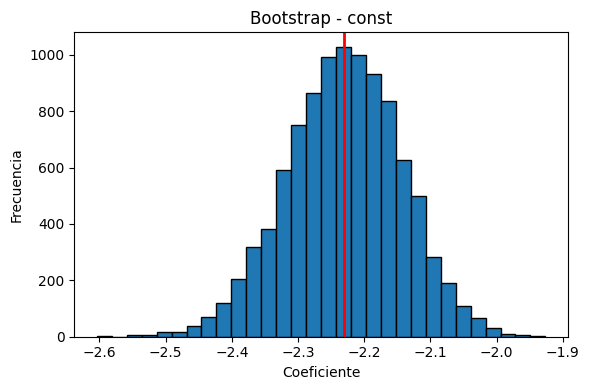

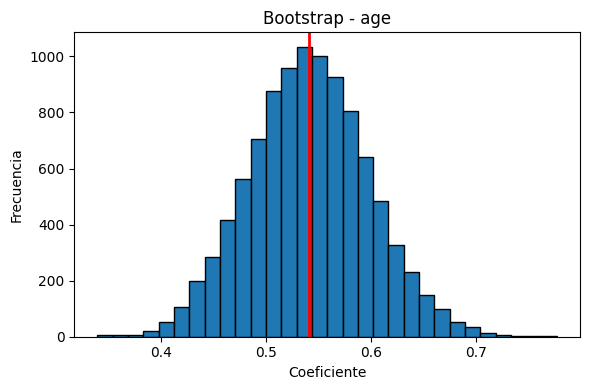

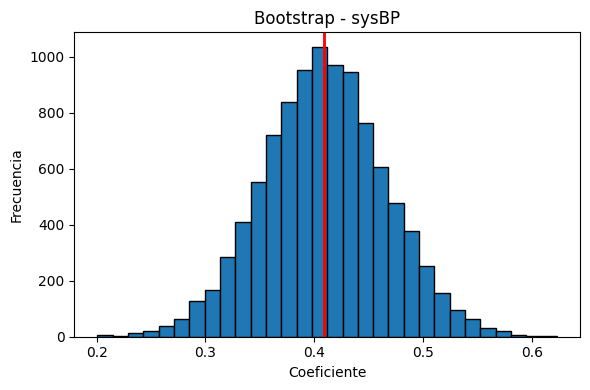

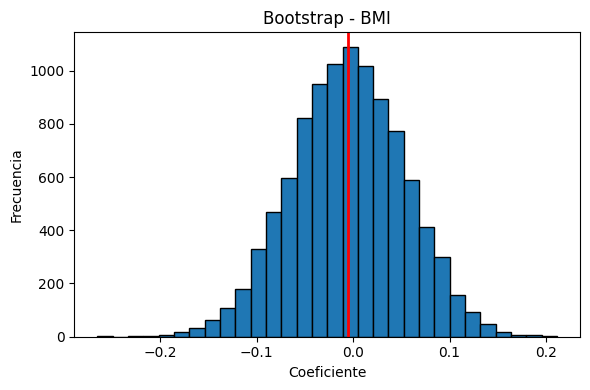

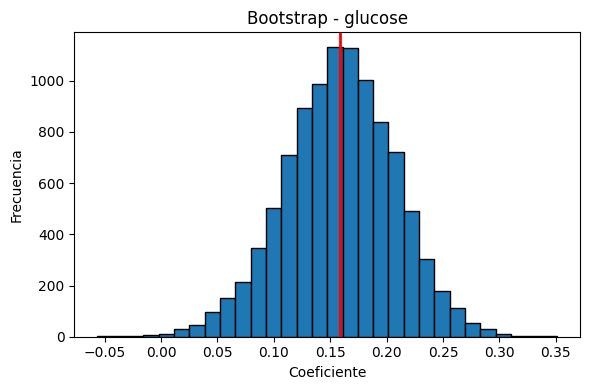

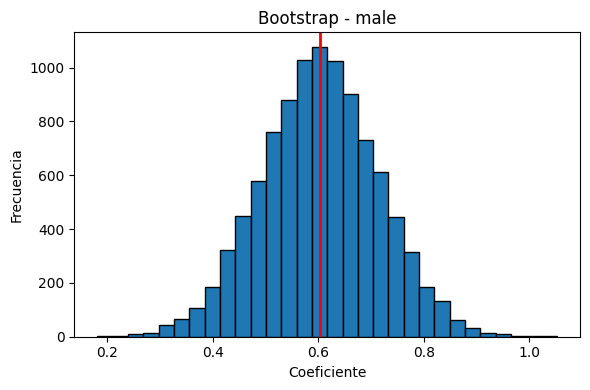

In [100]:
# ==========================================
# Distribuciones Bootstrap
# ==========================================

for i, variable in enumerate(variables):

    plt.figure(figsize=(6,4))

    plt.hist(

        coef_boot[:,i],

        bins=30,

        edgecolor="black"

    )

    plt.axvline(

        bootstrap_ic.loc[i,"Coeficiente medio"],

        color="red",

        linewidth=2

    )

    plt.title(f"Bootstrap - {variable}")

    plt.xlabel("Coeficiente")

    plt.ylabel("Frecuencia")

    plt.tight_layout()

    plt.show()

**Interpretación**

Las distribuciones bootstrap presentan una dispersión acotada y centrada alrededor de los coeficientes estimados por máxima verosimilitud. Esto indica que los parámetros del modelo son estables frente al remuestreo y respalda la robustez de las estimaciones obtenidas.

In [101]:
# ==========================================
# Comparación Bootstrap vs Modelo
# ==========================================

comparacion = pd.DataFrame({

    "Variable": resultado1.params.index,

    "Coeficiente modelo": resultado1.params.values,

    "Coeficiente bootstrap": bootstrap_ic["Coeficiente medio"]

})

display(

    comparacion.round(4)

)

,Variable,Coeficiente modelo,Coeficiente bootstrap
0,const,-2.2235,-2.2306
1,age,0.5392,0.5407
2,sysBP,0.4074,0.4091
3,BMI,-0.0048,-0.0053
4,glucose,0.1590,0.1586
5,male,0.5995,0.6027


### Interpretación

Los coeficientes obtenidos mediante bootstrap presentan una elevada estabilidad respecto al modelo original.

Los intervalos de confianza bootstrap muestran una alta concordancia con los coeficientes estimados mediante máxima verosimilitud, indicando que las variables seleccionadas mantienen un comportamiento consistente frente al remuestreo.

Este resultado respalda la robustez del modelo seleccionado y confirma la estabilidad de los principales predictores identificados durante las Sumativas 1 y 2.

# Parte 4 - Diagnóstico del modelo logístico

## 15. Diagnóstico de supuestos

Se evalúan distintos aspectos del modelo logístico seleccionado para verificar su estabilidad y la validez de sus estimaciones.

Se consideran:

- Multicolinealidad mediante VIF.
- Observaciones influyentes.
- Residuos del modelo.

In [102]:
# ==========================================
# VIF del modelo final
# ==========================================

X_vif = sm.add_constant(
    X_train_scaled
)

vif = pd.DataFrame({

    "Variable": X_vif.columns,

    "VIF":[

        variance_inflation_factor(
            X_vif.values,
            i
        )

        for i in range(X_vif.shape[1])

    ]

})

display(vif.round(3))

,Variable,VIF
0,const,1.772
1,age,1.193
2,sysBP,1.318
3,BMI,1.131
4,glucose,1.025
5,male,1.012


### Interpretación del VIF

Valores de VIF inferiores a 5 indican ausencia de problemas relevantes de multicolinealidad.

Los resultados obtenidos son consistentes con los análisis realizados durante la Sumativa 2, donde ya se había identificado que las variables seleccionadas no presentaban colinealidad preocupante.

### Figura 4. Identificación de observaciones potencialmente influyentes mediante la distancia de Cook

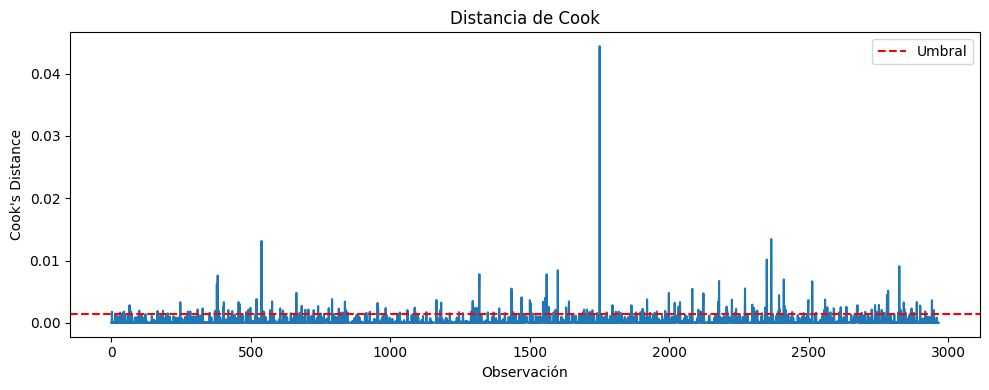

In [103]:
# ==========================================
# Observaciones influyentes
# ==========================================

influencia = resultado1.get_influence()

cook = influencia.cooks_distance[0]

plt.figure(figsize=(10,4))

plt.plot(cook)

plt.axhline(

    4/len(cook),

    color="red",

    linestyle="--",

    label="Umbral"

)

plt.title("Distancia de Cook")

plt.xlabel("Observación")

plt.ylabel("Cook's Distance")

plt.legend()

plt.tight_layout()

plt.show()

**Interpretación**

La mayoría de las observaciones presentan una influencia reducida sobre el ajuste del modelo. Los pocos casos con mayor distancia de Cook no evidencian un impacto suficiente para justificar su eliminación, por lo que el modelo puede considerarse estable frente a observaciones individuales.

In [104]:
# ==========================================
# Observaciones influyentes
# ==========================================

top_cook = pd.DataFrame({

    "Observación":

        np.arange(len(cook)),

    "Cook":

        cook

})

top_cook = top_cook.sort_values(

    "Cook",

    ascending=False

).head(10)

display(top_cook)

,Observación,Cook
1750,1750,0.044404
2365,2365,0.013449
538,538,0.013144
2349,2349,0.010163
2824,2824,0.009101
1600,1600,0.008450
1560,1560,0.007804
1319,1319,0.007800
381,381,0.007601
2410,2410,0.006975


### Figura 5. Distribución de los residuos del modelo logístico

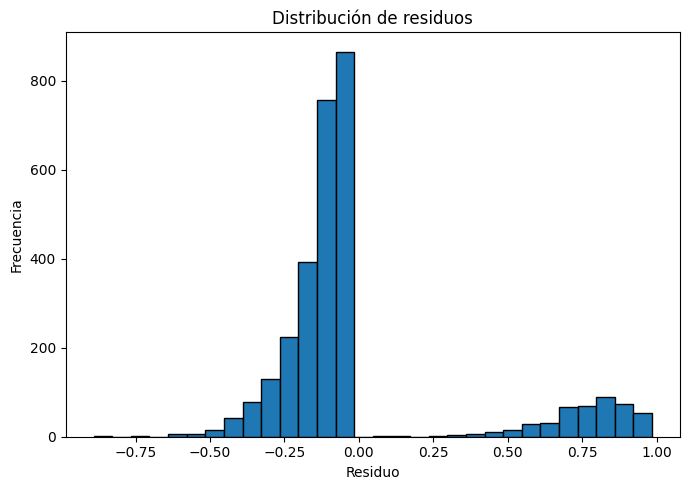

In [105]:
# ==========================================
# Residuos
# ==========================================

residuos = resultado1.resid_response

plt.figure(figsize=(7,5))

plt.hist(

    residuos,

    bins=30,

    edgecolor="black"

)

plt.title("Distribución de residuos")

plt.xlabel("Residuo")

plt.ylabel("Frecuencia")

plt.tight_layout()

plt.show()

**Interpretación**

La distribución observada de los residuos no presenta patrones anómalos evidentes y resulta consistente con el comportamiento esperado para un modelo de regresión logística. No se identifican indicios que sugieran problemas importantes en el ajuste global del modelo.

### Interpretación

El análisis de diagnóstico indica que el modelo seleccionado presenta un comportamiento estable.

No se observan problemas importantes de multicolinealidad y las observaciones influyentes corresponden a un número reducido de casos, sin afectar de forma significativa la estabilidad general del modelo.

La distribución de residuos resulta consistente con el comportamiento esperado para un modelo de regresión logística.

# Parte 5 - Impacto de la estrategia de imputación

En esta etapa se compara el efecto de las tres estrategias de tratamiento de datos faltantes sobre el desempeño del modelo de regresión logística.

Las estrategias comparadas son:

- Eliminación de observaciones (`dropna`)
- Imputación simple
- Imputación mediante regresión

La comparación considera:

- tamaño muestral;
- accuracy;
- AUC;
- coeficientes estimados.

In [108]:
# ==========================================
# Función de evaluación
# ==========================================

def evaluar_dataset(dataset, nombre):

    X = dataset[features]

    y = dataset[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=TEST_SIZE,

        random_state=SEED,

        stratify=y

    )

    X_train = X_train.copy()

    X_test = X_test.copy()

    scaler = StandardScaler()

    X_train[variables_numericas] = scaler.fit_transform(
        X_train[variables_numericas]
    )

    X_test[variables_numericas] = scaler.transform(
        X_test[variables_numericas]
    )

    modelo = LogisticRegression(
        max_iter=1000,
        random_state=SEED
    )

    modelo.fit(
        X_train,
        y_train
    )

    prob = modelo.predict_proba(
        X_test
    )[:,1]

    pred = modelo.predict(
        X_test
    )

    return {

    "Dataset": nombre,

    "Observaciones": len(dataset),

    "Accuracy": accuracy_score(
        y_test,
        pred
    ),

    "AUC": roc_auc_score(
        y_test,
        prob
    ),

    "Coef_age": modelo.coef_[0][0],

    "Coef_sysBP": modelo.coef_[0][1],

    "Coef_BMI": modelo.coef_[0][2],

    "Coef_glucose": modelo.coef_[0][3],

    "Coef_male": modelo.coef_[0][4]

}

In [113]:
# ==========================================
## Comparación del impacto de las estrategias de imputación
# ==========================================

comparacion_imputacion = pd.DataFrame([

    evaluar_dataset(

        df_dropna,

        "Eliminación"

    ),

    evaluar_dataset(

        df_simple,

        "Imputación simple"

    ),

    evaluar_dataset(

        df_model,

        "Imputación regresión"

    )

])

display(

    comparacion_imputacion.round(4)

)

,Dataset,Observaciones,Accuracy,AUC,Coef_age,Coef_sysBP,Coef_BMI,Coef_glucose,Coef_male
0,Eliminación,3656,0.8523,0.7465,0.5075,0.4015,0.0366,0.1410,0.5883
1,Imputación simple,4238,0.8506,0.6999,0.5378,0.4066,-0.0038,0.1530,0.5920
2,Imputación regresión,4238,0.8506,0.6995,0.5368,0.4063,-0.0041,0.1591,0.5919


## Interpretación

La imputación mediante regresión permitió conservar el tamaño muestral completo, manteniendo un desempeño predictivo comparable al obtenido con las demás estrategias.

La eliminación de observaciones redujo el número de registros disponibles para el entrenamiento del modelo, mientras que la imputación simple preservó el tamaño muestral, aunque con una ligera pérdida de variabilidad en las variables imputadas.

En consecuencia, la imputación mediante regresión fue seleccionada como la estrategia más adecuada para el desarrollo del modelo final.

In [110]:
# ==========================================
# Exportación resultados
# ==========================================

comparacion_modelos.to_csv(

    RESULTS_DIR /
    "comparacion_modelos.csv",

    index=False

)

comparacion_imputacion.to_csv(

    RESULTS_DIR /
    "comparacion_imputacion.csv",

    index=False

)

bootstrap_ic.to_csv(

    RESULTS_DIR /
    "bootstrap_coeficientes.csv",

    index=False

)

odds_bootstrap.to_csv(

    RESULTS_DIR /
    "bootstrap_odds_ratio.csv",

    index=False

)

print("Resultados exportados correctamente.")

Resultados exportados correctamente.


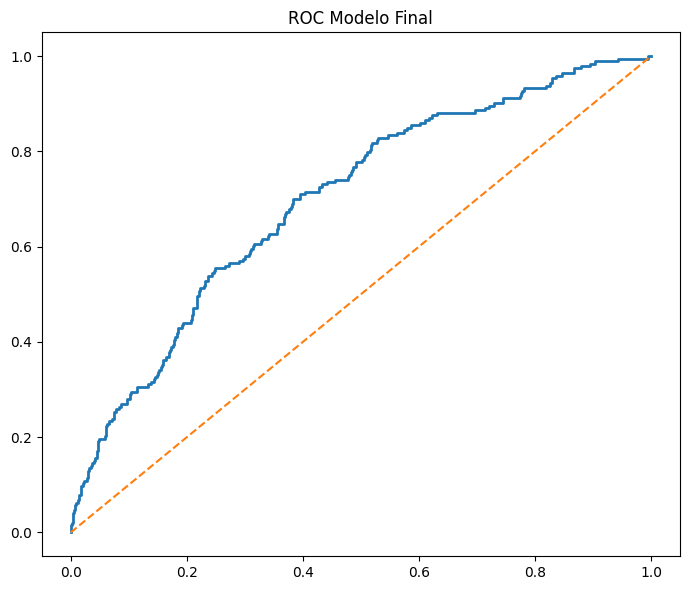

In [111]:
# ==========================================
# Exportar última figura ROC
# ==========================================

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.title("ROC Modelo Final")

plt.tight_layout()

plt.savefig(

    FIGURES_DIR /
    "roc_modelo_final.png",

    dpi=300

)

plt.show()

# Integración metodológica del proyecto (S1 → S2 → S3)

El presente proyecto fue desarrollado siguiendo una estrategia progresiva de análisis de datos, donde cada fase entregó información fundamental para sustentar las decisiones metodológicas de la etapa siguiente.

## Sumativa 1 (S1): Exploración y análisis inferencial

Durante la primera etapa se caracterizó el conjunto de datos mediante estadística descriptiva e inferencial. Se identificaron las variables con mayor relación respecto de la variable objetivo (TenYearCHD), se analizaron los valores faltantes, se detectaron observaciones atípicas y se estimaron parámetros poblacionales mediante intervalos de confianza y pruebas de hipótesis.

Estos resultados permitieron seleccionar las variables candidatas para el modelamiento predictivo.

---

## Sumativa 2 (S2): Validación mediante remuestreo

En la segunda etapa se evaluó la robustez de los resultados obtenidos en S1 utilizando bootstrap, pruebas de permutación, simulación Monte Carlo y análisis de sensibilidad.

Las correlaciones validadas como estables y los parámetros robustos obtenidos fueron utilizados como base para seleccionar las variables incluidas posteriormente en los modelos de regresión logística.

---

## Sumativa 3 (S3): Modelamiento predictivo

En esta etapa se implementó una estrategia de imputación de datos faltantes, se compararon distintos métodos de tratamiento de datos incompletos y se desarrollaron tres modelos de regresión logística utilizando diferentes criterios de selección de variables.

Posteriormente se evaluó la estabilidad del modelo seleccionado mediante bootstrap, se analizaron sus supuestos estadísticos y se comparó el impacto de las distintas estrategias de imputación sobre el desempeño predictivo.

---

## Integración final

La progresión metodológica entre S1, S2 y S3 permitió construir un proceso analítico coherente y reproducible. Los resultados exploratorios obtenidos inicialmente fueron validados mediante técnicas de remuestreo y posteriormente utilizados para construir modelos predictivos fundamentados estadísticamente, fortaleciendo la confiabilidad de las conclusiones obtenidas y apoyando la toma de decisiones basada en evidencia.

La integración entre las tres etapas permitió que cada decisión metodológica estuviera sustentada en evidencia obtenida previamente, evitando análisis aislados y fortaleciendo la trazabilidad del proyecto desde la exploración inicial de los datos hasta la construcción y validación del modelo predictivo final.

# Conclusiones

Los resultados obtenidos demuestran que la integración de las tres etapas del proyecto permitió construir un modelo predictivo robusto y metodológicamente consistente.

Las decisiones adoptadas durante la Sumativa 3 se fundamentaron directamente en los análisis exploratorios e inferenciales realizados en la Sumativa 1 y en las validaciones mediante bootstrap, permutación y simulación Monte Carlo desarrolladas en la Sumativa 2.

El modelo logístico seleccionado mostró un desempeño estable y coeficientes consistentes bajo remuestreo bootstrap, mientras que la imputación mediante regresión permitió conservar la información disponible sin afectar de manera relevante la capacidad predictiva del modelo.

En conjunto, los resultados evidencian una adecuada trazabilidad metodológica entre S1, S2 y S3, cumpliendo el objetivo del proyecto de apoyar la toma de decisiones mediante técnicas de análisis de datos y modelamiento predictivo.